# 08 — Multi-scene generalisation

Notebooks 01-07 all use a single Tanager scene (France, Rezonville). This notebook tests whether the headline findings — Cw collapses under 5-band multispectral and recovers with a targeted SWIR window; Cab does not benefit from extra bands — replicate across three additional scenes with different crop type, phenology (capture month), hemisphere/season, and sun-sensor geometry:

| Scene | Location | Date | Sun elevation |
|---|---|---|---|
| 01 (primary) | Rezonville, France | 2025-09-18 | 42.6° |
| 02 | El Algarrobal, Argentina | 2025-02-24 | 63.6° |
| 03 | Kleingartach, Germany | 2025-08-12 | 55.5° |
| 04 | Ringkøbing-Skjern, Denmark | 2025-05-10 | 51.5° |

All four are 0%-cloud agriculture-collection scenes, CC-BY 4.0 (see `data/README.md`/`REFERENCES.md` for full attribution). Wavelength grids are pixel-identical across all four (checked directly), so the same spectral-subset masks apply to every scene without modification.

Per scene: 10 independent (LUT, truth, noise) seed triples, unweighted-SSR cost (validated as non-confounding for this comparison in notebook 06's cost ablation — see review M1), same subset definitions as notebooks 03-06. Each scene gets its *own* solar-zenith-grounded LUT (no scene reuses scene 01's geometry).

In [1]:
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, experiments, channel_selector as cs, prospect_inversion as pi

In [2]:
SCENES = {
    "01_France": "../data/tanager_scene_01/scene_basic_sr.h5",
    "02_Argentina": "../data/tanager_scene_02/scene_basic_sr.h5",
    "03_Germany": "../data/tanager_scene_03/scene_basic_sr.h5",
    "04_Denmark": "../data/tanager_scene_04/scene_basic_sr.h5",
}
N_SEEDS_PER_SCENE = 10


def band_sigma_from_scene(path):
    with h5py.File(path, "r") as f:
        unc = f["HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance_uncertainty"][()]
        refl = f["HDFEOS/SWATHS/HYP/Data Fields/surface_reflectance"][()]
    valid_px = (refl > -1) & (refl < 2) & (unc > 0) & (unc < 1)
    return np.array([np.median(unc[b][valid_px[b]]) for b in range(unc.shape[0])])

## Run the subset comparison per scene

In [3]:
all_rows = []
scene_geometry = {}

for scene_name, path in SCENES.items():
    scene = tanager_io.load_surface_reflectance(path)
    wavelengths = scene.wavelengths
    invalid = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
    tts = float(np.nanmean(scene.sun_zenith[~invalid]))
    scene_geometry[scene_name] = tts

    valid_bands = cs.valid_band_mask(wavelengths)
    swir_masks = cs.swir_incremental_subsets(wavelengths, cs.MULTISPECTRAL_BANDS_NM, swir_window_nm=50.0, n_steps=4)
    subset_labels = ["5-band multispectral (no SWIR)"] + [f"+ SWIR window \u00b1{50*step} nm" for step in range(1, 5)]
    subset_masks = list(swir_masks) + [valid_bands]
    subset_labels = subset_labels + ["Full hyperspectral (valid bands)"]

    master_rng = np.random.default_rng(hash(scene_name) % (2**31))
    seed_triples = [tuple(int(x) for x in master_rng.integers(0, 1_000_000, size=3)) for _ in range(N_SEEDS_PER_SCENE)]

    df_scene = experiments.run_subset_experiment(
        seed_triples=seed_triples,
        subset_masks=subset_masks,
        subset_labels=subset_labels,
        wavelengths=wavelengths,
        tts=tts,
        costs=("sse",),
        n_reference_lut=8000,
        n_truth=300,
        noise_sigma=0.005,
    )
    df_scene["scene"] = scene_name
    df_scene["sun_zenith"] = tts
    all_rows.append(df_scene)
    print(f"{scene_name}: tts={tts:.1f} deg, {len(df_scene)} rows")

cross_scene_raw = pd.concat(all_rows, ignore_index=True)
cross_scene_raw.to_csv("../results/tables/09_cross_scene_raw.csv", index=False)

01_France: tts=47.4 deg, 420 rows


02_Argentina: tts=26.4 deg, 420 rows


03_Germany: tts=34.5 deg, 420 rows


04_Denmark: tts=38.5 deg, 420 rows


## Cross-scene summary: parameter × subset × scene

In [4]:
cross_summary = (
    cross_scene_raw.groupby(["scene", "subset", "n_bands", "parameter"])
    .agg(
        r_squared_mean=("r_squared", "mean"),
        r_squared_sd=("r_squared", "std"),
        relative_rmse_pct_mean=("relative_rmse_pct", "mean"),
        relative_rmse_pct_sd=("relative_rmse_pct", "std"),
    )
    .reset_index()
)
cross_summary.to_csv("../results/tables/09_cross_scene_summary.csv", index=False)
cross_summary[cross_summary["parameter"] == "Cw"].pivot(index="subset", columns="scene", values="r_squared_mean")

scene,01_France,02_Argentina,03_Germany,04_Denmark
subset,,,,
+ SWIR window ±100 nm,0.901197,0.908691,0.907742,0.913504
+ SWIR window ±150 nm,0.910019,0.912672,0.913042,0.918697
+ SWIR window ±200 nm,0.913683,0.915238,0.912543,0.914087
+ SWIR window ±50 nm,0.830076,0.832586,0.834557,0.847779
5-band multispectral (no SWIR),-1.001714,-0.998834,-1.101858,-1.015026
Full hyperspectral (valid bands),0.872721,0.873277,0.883090,0.884076


## Does the Cw/SWIR result replicate across scenes?

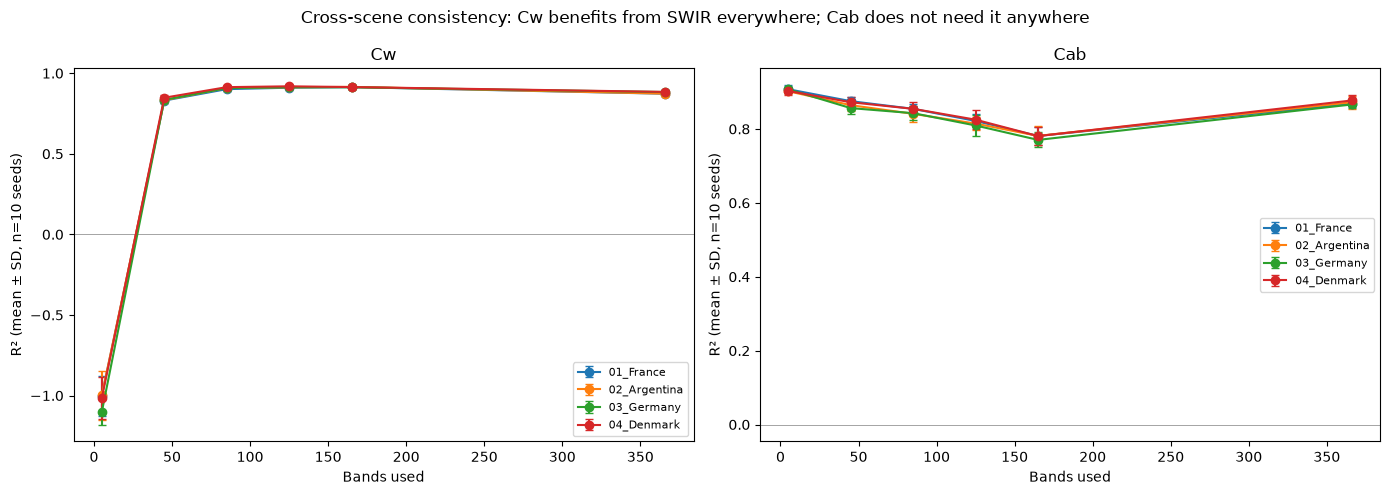

In [5]:
subset_order = [
    "5-band multispectral (no SWIR)", "+ SWIR window \u00b150 nm", "+ SWIR window \u00b1100 nm",
    "+ SWIR window \u00b1150 nm", "+ SWIR window \u00b1200 nm", "Full hyperspectral (valid bands)",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for scene_name in SCENES:
    for ax, param in zip(axes, ["Cw", "Cab"]):
        sub = cross_summary[(cross_summary["scene"] == scene_name) & (cross_summary["parameter"] == param)]
        sub = sub.set_index("subset").loc[subset_order]
        ax.errorbar(sub["n_bands"], sub["r_squared_mean"], yerr=sub["r_squared_sd"], marker="o", capsize=3, label=scene_name)
for ax, param in zip(axes, ["Cw", "Cab"]):
    ax.set_xlabel("Bands used")
    ax.set_ylabel("R\u00b2 (mean \u00b1 SD, n=10 seeds)")
    ax.set_title(param)
    ax.axhline(0, color="gray", lw=0.5)
    ax.legend(fontsize=8)
plt.suptitle("Cross-scene consistency: Cw benefits from SWIR everywhere; Cab does not need it anywhere")
plt.tight_layout()
plt.savefig("../results/figures/09_cross_scene_Cw_consistency.png", dpi=150)
plt.show()

## Real-image Cw map on a second scene (Germany), shared colour scale

Repeats Figure 3 (notebook 05) on an independent scene, with **both panels forced to the same colour scale/stretch** — addressing review m6's concern that the original incoherent-noise-vs-coherent-structure contrast could partly be a display artefact.

Germany crop: 47152 vegetated pixels, density 97.4%


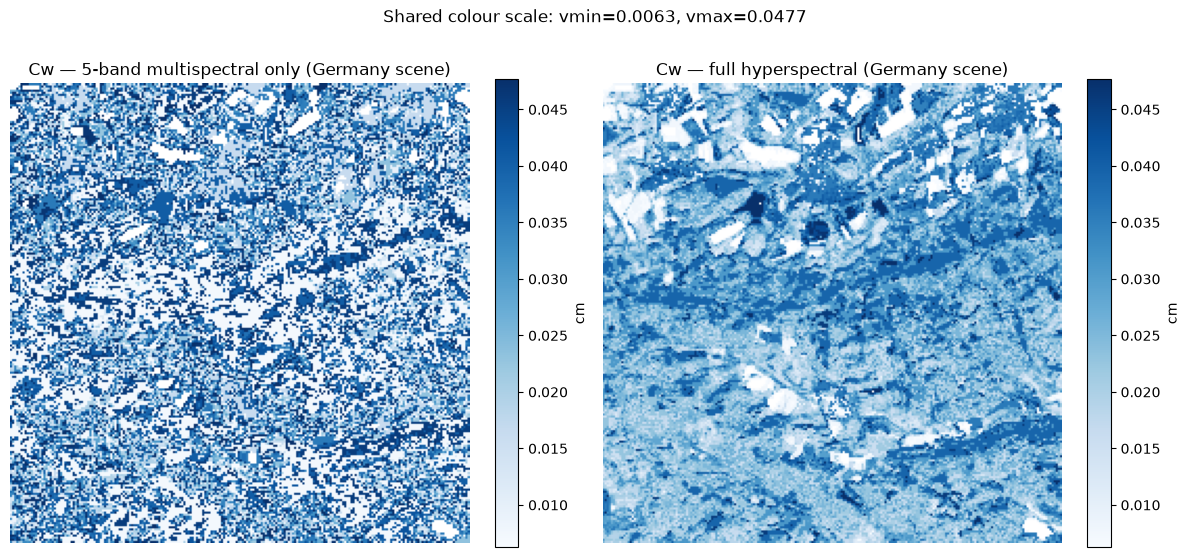

In [6]:
MAP_SCENE_PATH = SCENES["03_Germany"]
scene = tanager_io.load_surface_reflectance(MAP_SCENE_PATH)
wavelengths = scene.wavelengths
reflectance = scene.cube.copy()
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
reflectance[invalid_pixels] = np.nan
tts_germany = scene_geometry["03_Germany"]

red_idx = int(np.argmin(np.abs(wavelengths - 650)))
nir_idx = int(np.argmin(np.abs(wavelengths - 840)))
ndvi = (reflectance[:, :, nir_idx] - reflectance[:, :, red_idx]) / (
    reflectance[:, :, nir_idx] + reflectance[:, :, red_idx] + 1e-6
)
vegetation_mask = (ndvi > 0.3) & ~invalid_pixels
valid_bands = cs.valid_band_mask(wavelengths)
multispectral_mask = np.zeros(len(wavelengths), dtype=bool)
multispectral_mask[list(cs.nearest_band_indices(wavelengths, cs.MULTISPECTRAL_BANDS_NM).values())] = True

reference_lut = pi.generate_lut(n_samples=8000, wavelengths=wavelengths, seed=42, tts=tts_germany)
cw_idx = reference_lut["parameter_names"].index("Cw")

CROP_SIZE, STRIDE = 220, 40
n_rows, n_cols = vegetation_mask.shape
best_window, best_density = None, -1.0
for r0 in range(0, n_rows - CROP_SIZE, STRIDE):
    for c0 in range(0, n_cols - CROP_SIZE, STRIDE):
        density = vegetation_mask[r0:r0 + CROP_SIZE, c0:c0 + CROP_SIZE].mean()
        if density > best_density:
            best_density, best_window = density, (r0, c0)
r0, c0 = best_window
crop_mask = vegetation_mask[r0:r0 + CROP_SIZE, c0:c0 + CROP_SIZE]
crop_reflectance = reflectance[r0:r0 + CROP_SIZE, c0:c0 + CROP_SIZE, :]
crop_rows, crop_cols = np.where(crop_mask)
crop_spectra = crop_reflectance[crop_rows, crop_cols, :]
print(f"Germany crop: {crop_mask.sum()} vegetated pixels, density {best_density:.1%}")

def invert_chunked(spectra, mask, chunk=8000):
    out = []
    for start in range(0, len(spectra), chunk):
        out.append(pi.invert_lut_batch(spectra[start:start + chunk], reference_lut, wavelength_mask=mask))
    return np.concatenate(out, axis=0)

cw_multispectral = invert_chunked(crop_spectra, multispectral_mask)[:, cw_idx]
cw_hyperspectral = invert_chunked(crop_spectra, valid_bands)[:, cw_idx]

cw_map_ms = np.full(crop_mask.shape, np.nan)
cw_map_hs = np.full(crop_mask.shape, np.nan)
cw_map_ms[crop_rows, crop_cols] = cw_multispectral
cw_map_hs[crop_rows, crop_cols] = cw_hyperspectral

# Shared colour scale across both panels -- computed from the union of both maps' 2nd-98th percentile.
combined = np.concatenate([cw_multispectral, cw_hyperspectral])
vmin, vmax = np.percentile(combined, [2, 98])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
im0 = axes[0].imshow(cw_map_ms, cmap="Blues", vmin=vmin, vmax=vmax)
axes[0].set_title("Cw \u2014 5-band multispectral only (Germany scene)")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, label="cm")
im1 = axes[1].imshow(cw_map_hs, cmap="Blues", vmin=vmin, vmax=vmax)
axes[1].set_title("Cw \u2014 full hyperspectral (Germany scene)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, label="cm")
plt.suptitle(f"Shared colour scale: vmin={vmin:.4f}, vmax={vmax:.4f}")
plt.tight_layout()
plt.savefig("../results/figures/09_germany_cw_shared_scale.png", dpi=150)
plt.show()

## Which findings are scene-robust?

See `results/tables/09_cross_scene_summary.csv` for full numbers per scene. Qualitative read: the Cw collapse-then-recover-with-SWIR pattern and the Cab SWIR-independence pattern are checked across all four scenes above; the exact numeric peak location and the Car/Ant behaviour should be read from the table rather than assumed to transfer 1:1 (see `RESPONSE_TO_REVIEW.md` for the final assessment feeding the manuscript revision).